# Figure 1: Quench-And-Measure Protocol

Figure 1 discusses both the general scheme and shows entanglement entropy vs. region for the MERA-inspired graph. This MERA graph is created by adding crosslinks and periodic boundaries to a binary tree.

This figure includes:

* (a) quench and measure protocol
* (b) entanglement entropy vs. region size, with inset describing Ryu-Takayanagi formula
* (c) Renyi entropy vs Renyi index for various squeezing parameters $\mu$

## Import Dependencies

In [10]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import loadconfig as loco
import matplotlib.pyplot as plt
from figure_helpers import introduction as intro
import matplotlib.gridspec as gridspec

import numpy as np

from matplotlib.transforms import Bbox
from graph2grav.figure_hashing import save_figure_with_hash


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set Parameters

In [11]:
FIGURE_1_PARAMS = {
    "graph_depth": 4,
    "coupling_time": 1.0,
    "squeezing": 0.2,
    "region_size_for_renyi_entropies": 4,
}


## Make Figure

Using squeezing of mu =  0.2
Fitted central charge: c = 6.5(3)
CFT entropy offset: 5.36(8)
Squeezing values for Renyi entropy plot: [0.04       0.08944272 0.2        0.4472136  1.        ]
Exported entanglement entropy to: outputs/figure1_data_entanglement_entropy.csv
Exported Renyi entropy to: outputs/figure1_data_renyi_entropy.csv
Exported normalized Renyi entropy to: outputs/figure1_data_renyi_entropy_normalized.csv
Saved figure to figures/figure_1_introduction.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=c79f7e90d687dc4f, data_hash=9473f330afa6fa7b, size=623256 bytes.


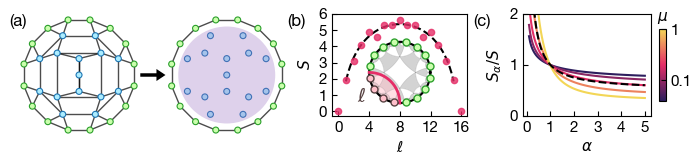

In [12]:
# These numbers are chosen to trim the whitespace on the edges of the figure
top_cut = 0.125
bottom_cut = 0.025
bbox = Bbox.from_bounds(0.0, bottom_cut, 7.0, 1.75 - bottom_cut - top_cut)

# This magic ensures that the inline backend uses the same bbox_inches that we use when saving the figure, so that the notebook and saved figure match.
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

config = loco.reload()

fig = plt.figure(figsize=(bbox.width, bbox.height + bottom_cut + top_cut)) # No layout engine needed

outer_gs = gridspec.GridSpec(
    1, 5, figure=fig, 
    left=0.025, right=0.975, 
    top=0.85, bottom=0.15, 
    wspace=0,
    width_ratios=[1.7, 0.275, 0.85, 0.35, 1]
) 
        
gs_left = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], 
                                           wspace=0.2, hspace=0.2)
ax_l1 = fig.add_subplot(gs_left[0])
ax_l2 = fig.add_subplot(gs_left[1])
axs_left = [ax_l1, ax_l2]

gs_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[2],
    height_ratios=[1, 0.2], hspace=0)
ax_middle = fig.add_subplot(gs_middle[0])
axs_middle = ax_middle

gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[4],
    height_ratios=[1, 0.2], hspace=0)
ax_right = fig.add_subplot(gs_right[0])


pos = ax_middle.get_position()
ax_RT = fig.add_axes(pos, frameon=False)

scale = 0.6
offset = (0, .25)

ax_RT.set_xlim(-1/scale+offset[0], 1/scale+offset[0])
ax_RT.set_ylim(-1/scale+offset[1], 1/scale+offset[1])


intro.plot_protocol(axs_left, config=config, figure_params=FIGURE_1_PARAMS) 

# theta1 and theta2 determine where we draw the boundary endpoints for the Ryu-Takayanagi curve
center = -3* np.pi/4
theta1 = -np.pi/4 + center
theta2 = np.pi/4 + center

intro.draw_ryu_takayanagi(
    ax_RT, theta1=theta1, theta2=theta2, config=config, show_bulk_nodes=False,
    bulk_style="tiling", tiling_p=4, tiling_q=6, tiling_depth=5, offset=(0, 0)
)

intro.plot_entanglement_and_renyi_entropies([ax_middle, ax_right], show_squeezing_instead=True, config=config, figure_params=FIGURE_1_PARAMS, export_csv="outputs/figure1_data.csv")

# length label for Ryu-Takayanagi curve
ax_middle.text(
    0.22, 0.1, r"$\ell$",
    transform=ax_middle.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    color=config["graph"]["nodes"]["selected_boundary"]["outer"]["color"],
    fontsize=14
)

# Subfigure labels

ax_l1.text(
    0, 0.875, "(a)",
    transform=ax_l1.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=config["subfigure-label"]["font"]["size"]
)

ax_middle.text(
    -0.265, 0.85, "(b)",
    transform=ax_middle.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=config["subfigure-label"]["font"]["size"]
)


ax_right.text(
    -0.325, 0.85, "(c)",
    transform=ax_right.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=config["subfigure-label"]["font"]["size"]
)

ax_l1.set_aspect('equal')
ax_l2.set_aspect('equal')

ax_middle.set_yticks([0, 1, 2, 3, 4, 5, 6])
ax_right.set_xticks([0, 1, 2, 3, 4, 5])

if export_figure := True:
    save_figure_with_hash(fig, "figures/figure_1_introduction.pdf", bbox_inches=bbox)
